<a href="https://colab.research.google.com/github/temesgenaddise/cosc-650-applied-llm-systems/blob/main/Week-5/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Assignment | RAG Pipeline with Retrieval Evaluation

This notebook:
             
              ==> ingests eight RAG documents,

              ==> compares three chunking configurations over ten queries,

              ==> reports chunk-level Precision and Recall @ top 5 chunks,

              ==> connects retrieval to gemini flash to answer the given prompt with evidence, and

              ==> documents one failure.

**Install and import the required packages, set reproducibility and model options, and load the sentence embedding model.**

In [1]:
%pip install -q sentence-transformers faiss-cpu pandas matplotlib seaborn google-genai

import os, pathlib, warnings, faiss, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
os.environ["HF_HOME"] = str((pathlib.Path(".") / ".hf_cache").resolve())
np.random.seed(42)
EMBEDDING_MODEL, TOP_K = "sentence-transformers/all-MiniLM-L6-v2", 5
embedder = SentenceTransformer(EMBEDDING_MODEL)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 64.5 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 1. Create the eight short source documents that make up the RAG corpus, and display their IDs and titles.

In [2]:
DOCUMENTS = [
{"doc_id": "D1", "title": "RAG Architecture", "text": """ Retrieval-augmented generation combines a retriever with a language model. At ingestion time, source documents are cleaned, split into chunks, embedded as vectors, and stored in an index. At query time, the same embedding family converts the user question into a vector. The system selects similar chunks and inserts them into a grounded prompt. The generator must answer from that supplied evidence rather than unsupported memory. RAG is useful when knowledge changes frequently or when an answer must be traceable to private sources. Evaluate the retriever and generator separately because fluent generation can hide retrieval mistakes. A production system also records source identifiers, similarity scores, latency, and the exact prompt used for each answer."""},
{"doc_id": "D2", "title": "Chunking Strategies", "text": """ Chunking divides long documents into retrievable units. Fixed-size chunking is simple and predictable, while sentence or section chunking better preserves meaning. Chunk overlap repeats boundary text so a fact near an edge is not separated from its explanation. Very small chunks can improve precision because each result is focused, but they may lose context and increase the number of vectors. Very large chunks preserve context and may improve recall, but they can mix topics and waste the prompt budget. A useful experiment varies chunk size and overlap while keeping the embedding model, query set, and top-k constant. Metadata such as document ID, heading, and character offsets should travel with every chunk."""},
{"doc_id": "D3", "title": "Embeddings and Similarity", "text": """ An embedding model maps text to a dense numerical vector. Semantically related passages should be close even when they use different vocabulary. Sentence-transformer models can run locally and are commonly used for RAG prototypes. The same model and normalization procedure must encode both corpus chunks and queries. With normalized vectors, the inner product equals cosine similarity. Domain-specific language can challenge a general-purpose embedding model, so compare models using a labeled query set. Embedding quality, vector dimension, speed, memory use, and licensing all matter when selecting a model."""},
{"doc_id": "D4", "title": "Vector Indexes and FAISS", "text": """ A vector index stores embeddings and searches for nearest neighbors. FAISS provides exact and approximate index types. IndexFlatIP performs exact inner-product search and suits a small evaluation corpus. Approximate indexes such as HNSW or IVF trade a small amount of recall for lower latency at large scale. Vectors must use float32 for common FAISS indexes. Returned row positions should be mapped back to chunk text and metadata. Similarity scores rank candidates but are not calibrated probabilities. Filters can restrict retrieval by tenant, date, language, or document type before or after vector search."""},
{"doc_id": "D5", "title": "Retrieval Evaluation", "text": """ Retrieval evaluation starts with a test set created independently of system output. For each query, evaluators decide which chunks satisfy the information need. Precision at k is the fraction of the k retrieved chunks that are relevant. Recall at k is the fraction of all relevant chunks that appear in the top k. Precision rewards focused results, while recall rewards coverage. Mean precision and mean recall summarize performance across queries, but per-query results reveal failures. Chunk-level labels must be regenerated consistently when chunk boundaries change. Other useful measures include hit rate, mean reciprocal rank, and normalized discounted cumulative gain. Evaluation should report top-k and the labeling rule."""},
{"doc_id": "D6", "title": "Grounded Generation", "text": """The generation stage assembles retrieved passages into a prompt. A grounded prompt tells the model to use only the provided context, cite source labels, and admit when evidence is insufficient. The context should include chunk identifiers so claims can be traced. Prompt length is limited, so irrelevant large chunks can crowd out useful evidence. Low temperature improves repeatability but does not guarantee factuality. The generator must not treat a retrieval score as proof that a passage is correct. Answer quality can be evaluated for correctness, faithfulness to context, completeness, and citation accuracy."""},
{"doc_id": "D7", "title": "Failure Modes and Mitigations", "text": """ RAG failures can occur during ingestion, retrieval, or generation. A boundary failure happens when chunking separates a key term from the sentence that explains it. Vocabulary mismatch occurs when the query and relevant passage use different words. Similar but wrong passages can rank highly when they share many terms with the query. Mitigations include overlap, semantic chunking, query rewriting, hybrid lexical and vector search, metadata filtering, reranking, and a larger candidate pool. If evidence is weak, the system should abstain rather than guess. Failure analysis should show the query, retrieved chunks, expected evidence, cause, and a targeted mitigation."""},
{"doc_id": "D8", "title": "Connecting Retrieval to Answer Quality", "text": """ Answer quality depends on both evidence availability and generator behavior. If no relevant chunk reaches the prompt, a grounded generator cannot produce a complete supported answer. High retrieval recall creates an upper bound on answer coverage, while high precision reduces distracting context. To connect the stages, run generation with results from each retrieval configuration and score whether required facts appear and whether citations point to relevant chunks. A controlled comparison keeps the question and generation settings fixed. Retrieval metrics and answer metrics can disagree: a single excellent chunk may support a correct answer even when precision at k is low, while several partially relevant chunks may still omit the decisive fact."""}
]


docs_df = pd.DataFrame(DOCUMENTS)
display(docs_df[["doc_id", "title"]])
print(f"Corpus: {len(DOCUMENTS)} documents")

,doc_id,title
0,D1,RAG Architecture
1,D2,Chunking Strategies
2,D3,Embeddings and Similarity
3,D4,Vector Indexes and FAISS
4,D5,Retrieval Evaluation
5,D6,Grounded Generation
6,D7,Failure Modes and Mitigations
7,D8,Connecting Retrieval to Answer Quality


Corpus: 8 documents


## 1.1. Define three word-based chunking configurations, build a normalized embedding index for each, and define the top-five retrieval function.

In [3]:
CHUNK_CONFIGS = {
    "small (80/20)": {"size": 80, "overlap": 20},
    "medium (160/40)": {"size": 160, "overlap": 40},
    "large (320/80)": {"size": 320, "overlap": 80},
}

def chunk_document(doc, size, overlap):
    words, chunks, step = doc["text"].split(), [], size - overlap
    for start in range(0, len(words), step):
        piece = words[start:start + size]
        if not piece: break
        chunks.append({"chunk_id": f'{doc["doc_id"]}_w{start:04d}',
                       "doc_id": doc["doc_id"], "title": doc["title"],
                       "start_word": start, "end_word": start + len(piece),
                       "text": " ".join(piece)})
        if start + size >= len(words): break
    return chunks

def build_chunks(config):
    return [c for d in DOCUMENTS for c in chunk_document(d, config["size"], config["overlap"])]

def build_index(chunks):
    vectors = embedder.encode([c["text"] for c in chunks], normalize_embeddings=True,
                              show_progress_bar=False).astype("float32")
    index = faiss.IndexFlatIP(vectors.shape[1]); index.add(vectors)
    return index

chunk_sets = {name: build_chunks(cfg) for name, cfg in CHUNK_CONFIGS.items()}
indexes = {name: build_index(chunks) for name, chunks in chunk_sets.items()}
for name, chunks in chunk_sets.items():
    print(f"{name:18s} -> {len(chunks)} chunks")

def retrieve(query, config_name, k=TOP_K):
    q = embedder.encode([query], normalize_embeddings=True).astype("float32")
    scores, positions = indexes[config_name].search(q, min(k, len(chunk_sets[config_name])))
    return [{**chunk_sets[config_name][i], "score": float(score), "rank": rank + 1}
            for rank, (i, score) in enumerate(zip(positions[0], scores[0])) if i >= 0]

small (80/20)      -> 16 chunks
medium (160/40)    -> 8 chunks
large (320/80)     -> 8 chunks


**Interpretation of the output.**

     The small 80-word size with 20-word overlap produced 16 chunks.

     The medium 160/40 and large 320/80 settings each produced 8 chunks.

     More chunks provide more candidate passages and can also yield overlapping matches.

## Part 2: Evaluate retrieval



Below cell defines is ten evaluation queries,their target documents and required text anchors, and the rule for labeling a chunk.

In [4]:
TEST_QUERIES = [
 {"qid": "Q1", "query": "What are the five main stages of a RAG pipeline?", "doc_id": "D1", "anchors":["ingestion", "chunks", "embedded", "index"]},
 {"qid": "Q2", "query": "Why is overlap used when splitting documents?", "doc_id":"D2", "anchors":["overlap", "boundary"]},
 {"qid": "Q3", "query": "When is inner product equivalent to cosine similarity?", "doc_id": "D3", "anchors":["normalized", "inner product", "cosine"]},
 {"qid": "Q4", "query": "Which FAISS index performs exact inner-product search?", "doc_id":"D4", "anchors":["indexflatip", "exact"]},
 {"qid": "Q5", "query": "How are precision at k and recall at k defined?", "doc_id": "D5", "anchors":["precision at k", "recall at k"]},
 {"qid": "Q6", "query": "What instructions should a grounded generation prompt include?", "doc_id": "D6", "anchors":["only", "context", "cite", "insufficient"]},
 {"qid": "Q7", "query": "What is a chunk-boundary failure and how can it be mitigated?", "doc_id":"D7", "anchors":["boundary", "overlap"]},
 {"qid": "Q8", "query": "How does retrieval recall affect possible answer coverage?", "doc_id":"D8", "anchors":["recall", "upper bound", "coverage"]},
 {"qid": "Q9", "query": "Why should similarity scores not be interpreted as probabilities?", "doc_id":"D4", "anchors":["scores", "probabilities"]},
 {"qid": "Q10", "query": "Why can retrieval metrics and answer metrics disagree?", "doc_id":"D8", "anchors":["metrics", "disagree", "single excellent chunk"]},
]

def is_relevant(chunk, case):
    text = chunk["text"].lower()
    return chunk["doc_id"] == case["doc_id"] and all(a.lower() in text for a in case["anchors"])

**Interpretation.**

     Each relevant chunk both matched the specified document ID and contained every listed anchor.

**2.1. Count all relevant chunks for each question under each chunking configuration before checking retrieval ranking.**

In [5]:
gold_rows = []
for config_name, chunks in chunk_sets.items():
    for case in TEST_QUERIES:
        gold_rows.append({"configuration": config_name, "qid": case["qid"],
                          "relevant_chunks": sum(is_relevant(c, case) for c in chunks)})
display(pd.DataFrame(gold_rows).pivot(index="qid", columns="configuration", values="relevant_chunks"))

configuration,large (320/80),medium (160/40),small (80/20)
qid,,,
Q1,1,1,1
Q10,1,1,1
Q2,1,1,1
Q3,1,1,1
Q4,1,1,1
Q5,1,1,1
Q6,1,1,1
Q7,1,1,1
Q8,1,1,1


**Interpretation of the output.**
     
     Each query has one gold chunk in the medium and large settings. In the small setting Q9 has two relevant chunks,
     while the other queries each have one.
     The duplicate for Q9 arised from the overlapping small windows and affected its recall.

**2.2. Retrieve the top five chunks for every query and configuration, calculate chunk-level Precision@5 and Recall@5, and average the scores.**

In [6]:
rows, retrieval_log = [], {}
for config_name in CHUNK_CONFIGS:
    for case in TEST_QUERIES:
        hits = retrieve(case["query"], config_name)
        retrieval_log[(config_name, case["qid"])] = hits
        retrieved_relevant = sum(is_relevant(h, case) for h in hits)
        total_relevant = sum(is_relevant(c, case) for c in chunk_sets[config_name])
        rows.append({"configuration": config_name, "qid": case["qid"],
                     "precision@5": retrieved_relevant / len(hits),
                     "recall@5": retrieved_relevant / total_relevant if total_relevant else 0.0,
                     "retrieved_relevant": retrieved_relevant, "total_relevant": total_relevant})

results_df = pd.DataFrame(rows)
summary_df = results_df.groupby("configuration")[["precision@5", "recall@5"]].mean().round(3)
display(summary_df)
print("")


,precision@5,recall@5
configuration,,
large (320/80),0.20,1.0
medium (160/40),0.20,1.0
small (80/20),0.22,1.0


**Interpretation of the output.**
  
     All three configurations reached mean Recall@5 of 1.0. Mean Precision@5 is 0.20 for medium and large and 0.22 for small.
     The small setting gains its slight precision advantage from retrieving two relevant chunks for Q9.

**2.3.  Show per-query Recall@5 and plot the mean precision and recall of each chunking configuration.**

configuration,large (320/80),medium (160/40),small (80/20)
qid,,,
Q1,1.0,1.0,1.0
Q10,1.0,1.0,1.0
Q2,1.0,1.0,1.0
Q3,1.0,1.0,1.0
Q4,1.0,1.0,1.0
Q5,1.0,1.0,1.0
Q6,1.0,1.0,1.0
Q7,1.0,1.0,1.0
Q8,1.0,1.0,1.0


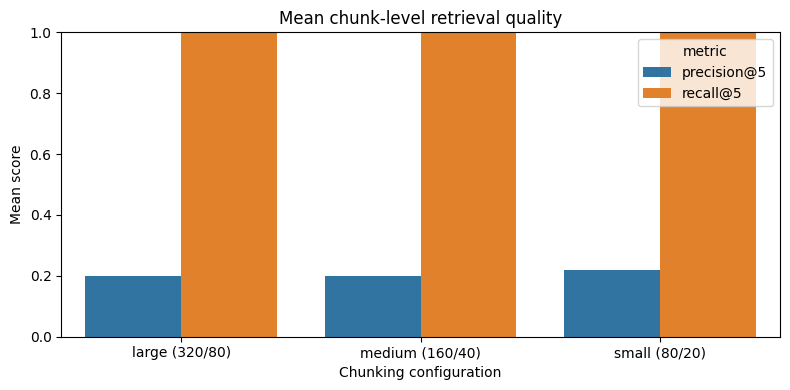

In [7]:
display(results_df.pivot(index="qid", columns="configuration", values="recall@5").round(2))
plot_df = summary_df.reset_index().melt("configuration", var_name="metric", value_name="score")
plt.figure(figsize=(8, 4)); sns.barplot(data=plot_df, x="configuration", y="score", hue="metric")
plt.ylim(0, 1); plt.title("Mean chunk-level retrieval quality")
plt.xlabel("Chunking configuration"); plt.ylabel("Mean score"); plt.tight_layout(); plt.show()

**Interpretation of the output.**

     Every query reaches Recall@5 of 1.0 in all three settings.
     The chart reflects this tie in recall and shows the small setting’s modest precision increase to 0.22 versus 0.20.

**2.4. Check whether the retrieved top-five context contains each query’s required anchors, then compare this coverage with recall.**

In [8]:
def evidence_coverage(case, hits):
    context = " ".join(h["text"].lower() for h in hits)
    return np.mean([anchor.lower() in context for anchor in case["anchors"]])

connection_rows = []
for config_name in CHUNK_CONFIGS:
    for case in TEST_QUERIES:
        metric = results_df[(results_df.configuration == config_name) &
                            (results_df.qid == case["qid"])].iloc[0]
        connection_rows.append({"configuration": config_name, "qid": case["qid"],
                                "recall@5": metric["recall@5"],
                                "prompt_fact_coverage": evidence_coverage(
                                    case, retrieval_log[(config_name, case["qid"])])})
connection_df = pd.DataFrame(connection_rows)
display(connection_df.groupby("configuration")[["recall@5", "prompt_fact_coverage"]].mean().round(3))
print("Recall/coverage correlation:",
      round(connection_df["recall@5"].corr(connection_df["prompt_fact_coverage"]), 3))

,recall@5,prompt_fact_coverage
configuration,,
large (320/80),1.0,1.0
medium (160/40),1.0,1.0
small (80/20),1.0,1.0


Recall/coverage correlation: nan


**Interpretation of the output.**

     Mean anchor coverage is 1.0 for all three configurations, as is mean Recall@5.
     The reported correlation is NaN, because recall never varied, so no correlation can be estimated.
     Anchor presence is a proxy for evidence availability; this cell does not evaluate generated answers.

# Part 3: Generate


In the cell below the configuration by mean recall and precision selected, a cited evidence prompt constructed, and a Gemini answer requested.

In [ ]:
import os
from openai import OpenAI
from google.colab import userdata

API_KEY = userdata.get("GEMINI_API_KEY")
if not API_KEY:
    raise RuntimeError("Add GEMINI_API_KEY to Colab Secrets before running the notebook.")

client = OpenAI(
    api_key=API_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)
MODEL = "gemini-3.8-flash"
print("Gemini client ready. Model:", MODEL)

# Submission to review.....

Gemini client ready. Model: gemini-3.8-flash


In [10]:
best_config = (summary_df.reset_index()
               .sort_values(["recall@5", "precision@5"], ascending=False)
               .iloc[0]["configuration"])
print("Selected configuration:", best_config)

def build_grounded_prompt(question, hits):
    context = "\n\n".join(
        f'[{h["chunk_id"]} | {h["title"]}]\n{h["text"]}' for h in hits
    )
    return f"""You are a grounded RAG assistant.
Use only the context below. Cite chunk IDs in square brackets after each supported claim.
If the context is insufficient, say exactly what is missing; do not guess.

QUESTION:
{question}

CONTEXT:
{context}

ANSWER:"""

def answer_with_gemini(question, config_name=best_config, k=TOP_K,
                       model_name=os.getenv("GEMINI_MODEL", "gemini-3.8-flash")):
    from google import genai

    global API_KEY
    if not API_KEY:
        raise RuntimeError("GEMINI_API_KEY is not available. Ensure it's set in Colab Secrets and the initialization cell has been run.")

    os.environ["GEMINI_API_KEY"] = API_KEY
    api_key = API_KEY

    hits = retrieve(question, config_name, k)
    prompt = build_grounded_prompt(question, hits)
    client = genai.Client(api_key=api_key)
    response = client.models.generate_content(model=model_name, contents=prompt)
    return response.text, hits

answer, evidence = answer_with_gemini("Why does chunk overlap help retrieval?", best_config)
print(answer,evidence)

Selected configuration: small (80/20)
Chunk overlap helps retrieval because:
* It repeats boundary text so that a fact located near the edge of a chunk is not separated from its explanation [D2_w0000].
* It serves as a mitigation for boundary failures, which occur when chunking separates a key term from the sentence that explains it [D7_w0000]. [{'chunk_id': 'D2_w0000', 'doc_id': 'D2', 'title': 'Chunking Strategies', 'start_word': 0, 'end_word': 80, 'text': 'Chunking divides long documents into retrievable units. Fixed-size chunking is simple and predictable, while sentence or section chunking better preserves meaning. Chunk overlap repeats boundary text so a fact near an edge is not separated from its explanation. Very small chunks can improve precision because each result is focused, but they may lose context and increase the number of vectors. Very large chunks preserve context and may improve recall, but they can mix topics and waste the prompt budget. A', 'score': 0.71216672658920

# Part 4 : Find One Failure and Explain it.



**Observed Possible chunk-boudary failure case:**

  Q7 asks, **“What is a chunk-boundary failure and how can it be mitigated?”** The relevance rule requires both *boundary* and *overlap* in chunk from D7. With small configuration windows, the definition and mitigation fell into different chunks. Neither isolated chunk fully answers the question, even if both are semantically related,leaving a retrieved passage unable to answer both parts of the question. But for all three chunk sizes configurations, the D7_w000  retrieved as rank 1.

In [11]:
failure_case = next(q for q in TEST_QUERIES if q["qid"] == "Q7")
for config_name in CHUNK_CONFIGS:
    print("\n", config_name.upper())
    print("Gold chunks:", [c["chunk_id"] for c in chunk_sets[config_name]
                           if is_relevant(c, failure_case)])
    for hit in retrieval_log[(config_name, "Q7")][:3]:
        print(f'  rank={hit["rank"]} score={hit["score"]:.3f} '
              f'{hit["chunk_id"]}: {hit["text"][:220]}...')


 SMALL (80/20)
Gold chunks: ['D7_w0000']
  rank=1 score=0.589 D7_w0000: RAG failures can occur during ingestion, retrieval, or generation. A boundary failure happens when chunking separates a key term from the sentence that explains it. Vocabulary mismatch occurs when the query and relevant ...
  rank=2 score=0.544 D2_w0000: Chunking divides long documents into retrievable units. Fixed-size chunking is simple and predictable, while sentence or section chunking better preserves meaning. Chunk overlap repeats boundary text so a fact near an ed...
  rank=3 score=0.454 D2_w0060: Very large chunks preserve context and may improve recall, but they can mix topics and waste the prompt budget. A useful experiment varies chunk size and overlap while keeping the embedding model, query set, and top-k co...

 MEDIUM (160/40)
Gold chunks: ['D7_w0000']
  rank=1 score=0.595 D7_w0000: RAG failures can occur during ingestion, retrieval, or generation. A boundary failure happens when chunking separates 

**Cause:** fixed word boundaries ignored semantic structure and separated a condition from its remedy.

**Mitigation:** increase overlap, use semantic or sentence-based chunking, retrieve a large candidate pool and merge adjacent chunks, or rerank parent sections.




## Part 5: submit
 Open a pull request with a result summary and review a classmate's Week 5 PR (the term's formal peer review). Use the rubric attached to the Canvas assignment for grading criteria and point values.